# Notebook 02 — Phân tích khám phá dữ liệu (EDA)

**Mục đích:** Phân tích và trực quan hóa đặc điểm biến động của PM2.5 tại Hà Nội 2022–2025.

**Đầu vào:** `data/processed/clean_data.csv`  
**Đầu ra:** Biểu đồ lưu tại `figures/`


In [1]:
import sys
from pathlib import Path
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processor import load_clean, split_train_test
from src.visualizer import (
    plot_time_series, plot_histogram, plot_boxplot_monthly,
    plot_monthly_mean, plot_acf_pacf
)
from src.config import TARGET_COL

df = load_clean()
print(f'Dữ liệu: {len(df)} ngày ({df.index.min().date()} → {df.index.max().date()})')

Dữ liệu: 1265 ngày (2022-01-13 → 2025-06-30)


## 1. Thống kê mô tả

In [2]:
desc = df[TARGET_COL].describe()
print(f'Trung bình:      {desc["mean"]:.2f} μg/m³')
print(f'Trung vị:        {desc["50%"]:.2f} μg/m³')
print(f'Độ lệch chuẩn:   {desc["std"]:.2f} μg/m³')
print(f'Min / Max:       {desc["min"]:.2f} / {desc["max"]:.2f} μg/m³')
print(f'Q25 / Q75:       {desc["25%"]:.2f} / {desc["75%"]:.2f} μg/m³')

Trung bình:      50.77 μg/m³
Trung vị:        41.50 μg/m³
Độ lệch chuẩn:   32.69 μg/m³
Min / Max:       2.33 / 261.01 μg/m³
Q25 / Q75:       28.97 / 62.69 μg/m³


## 2. Biểu đồ chuỗi thời gian

2026-08-05 20:47:31,719 [INFO] Đã lưu biểu đồ: D:\DuAn\QuanLyBuiMinPM25\figures\01_time_series.png


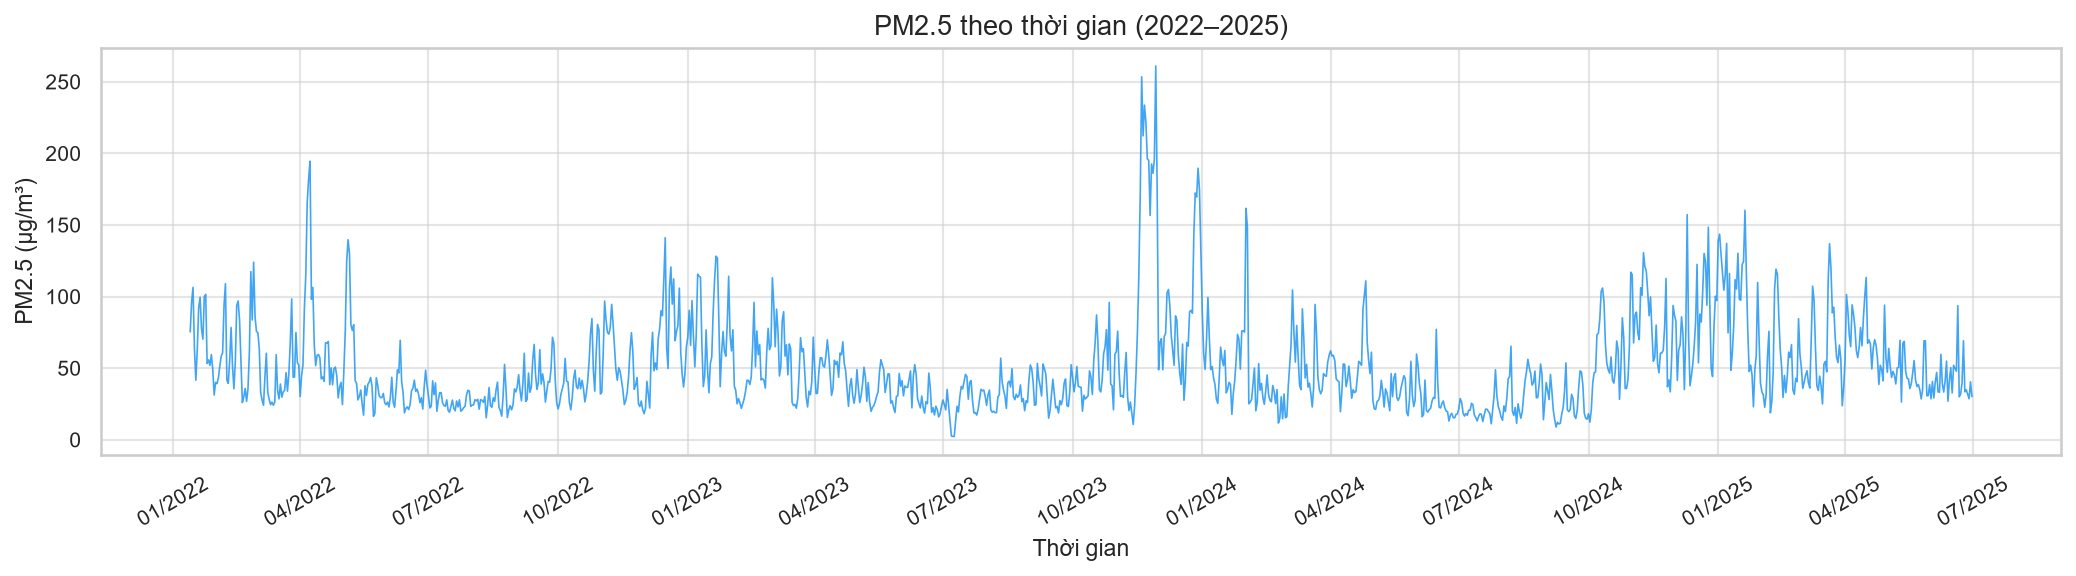

In [3]:
fig = plot_time_series(df)
plt.show()

## 3. Phân bố PM2.5 (Histogram)

2026-08-05 20:47:31,991 [INFO] Đã lưu biểu đồ: D:\DuAn\QuanLyBuiMinPM25\figures\02_histogram.png


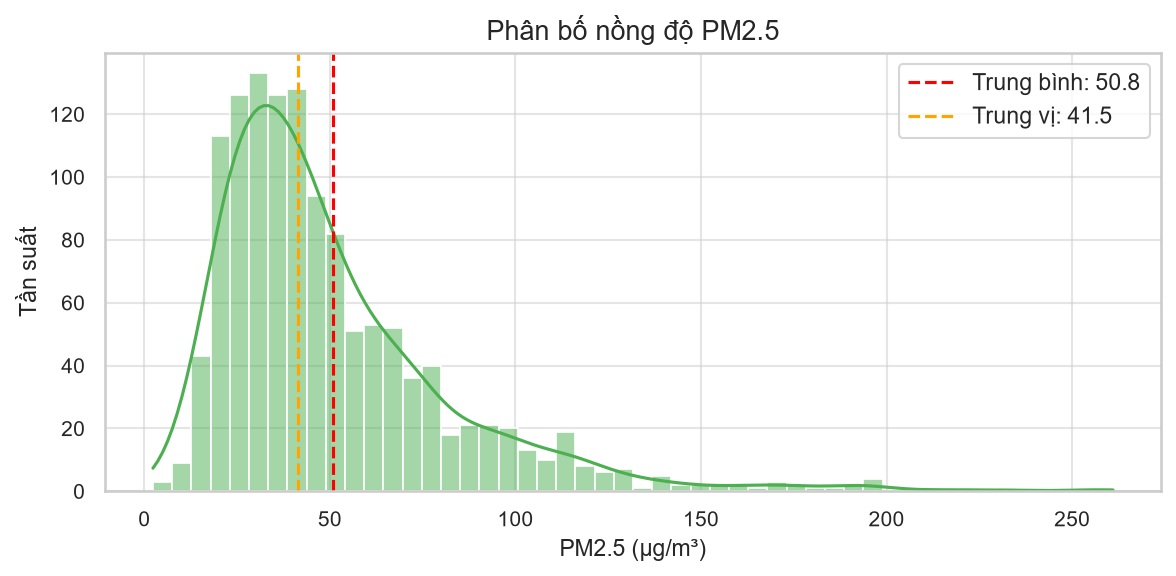

Độ lệch phân bố (skewness): 2.091
→ Phân bố lệch phải — có xu hướng tập trung ở giá trị thấp, một số đợt PM2.5 rất cao.


In [4]:
fig = plot_histogram(df)
plt.show()

skewness = df[TARGET_COL].skew()
print(f'Độ lệch phân bố (skewness): {skewness:.3f}')
if skewness > 0.5:
    print('→ Phân bố lệch phải — có xu hướng tập trung ở giá trị thấp, một số đợt PM2.5 rất cao.')

## 4. Boxplot theo tháng

2026-08-05 20:47:32,103 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
D:\DuAn\QuanLyBuiMinPM25\src\visualizer.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="month", y=TARGET_COL, ax=ax, palette="coolwarm")
2026-08-05 20:47:32,109 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
D:\DuAn\QuanLyBuiMinPM25\src\visualizer.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"T{m}" for m in r

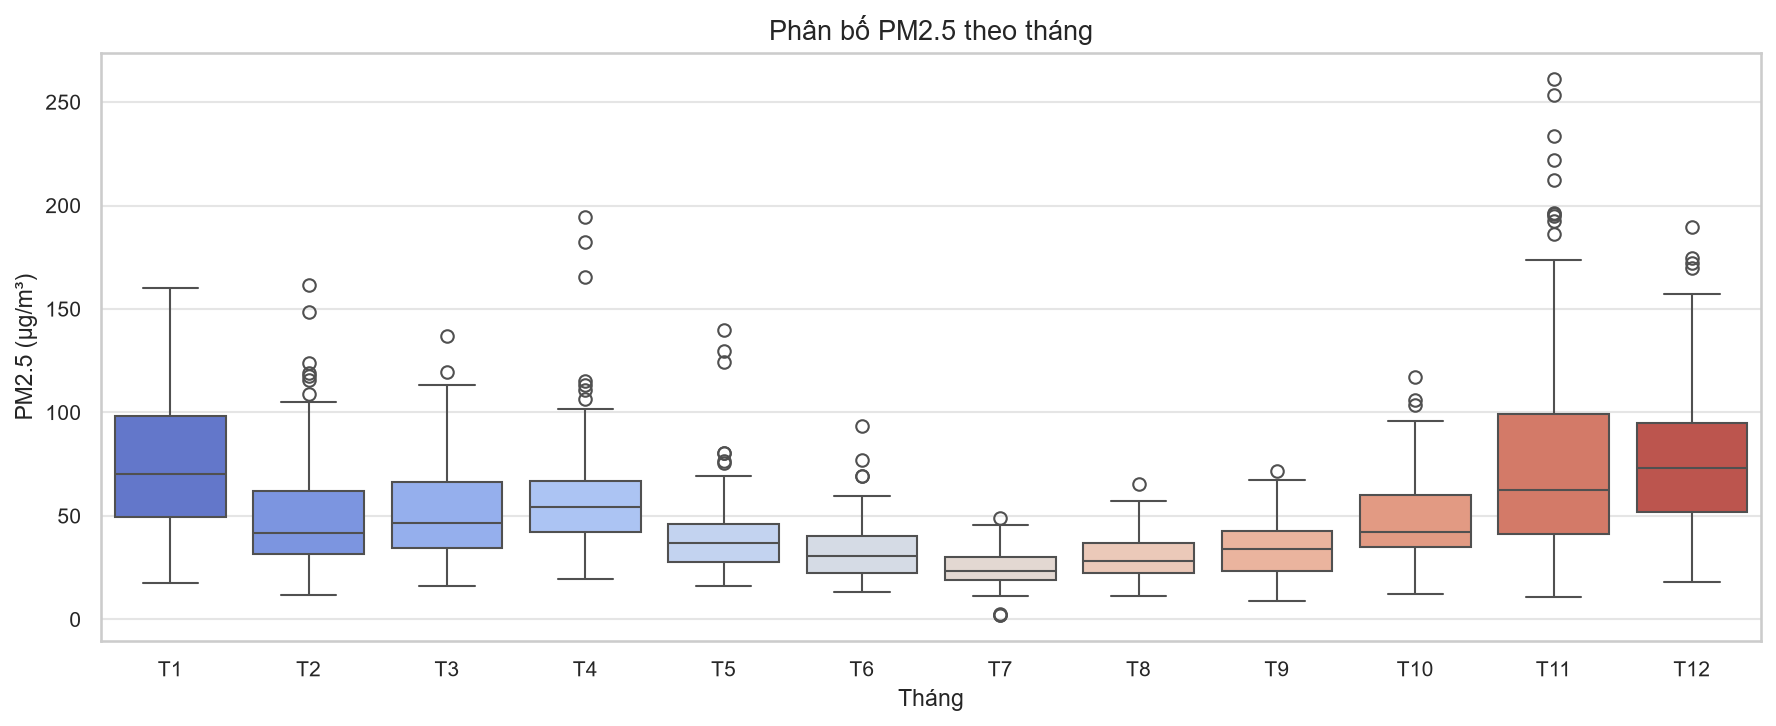

In [5]:
fig = plot_boxplot_monthly(df)
plt.show()

## 5. Trung bình PM2.5 theo tháng và năm

2026-08-05 20:47:32,522 [INFO] Đã lưu biểu đồ: D:\DuAn\QuanLyBuiMinPM25\figures\04_monthly_mean_by_year.png


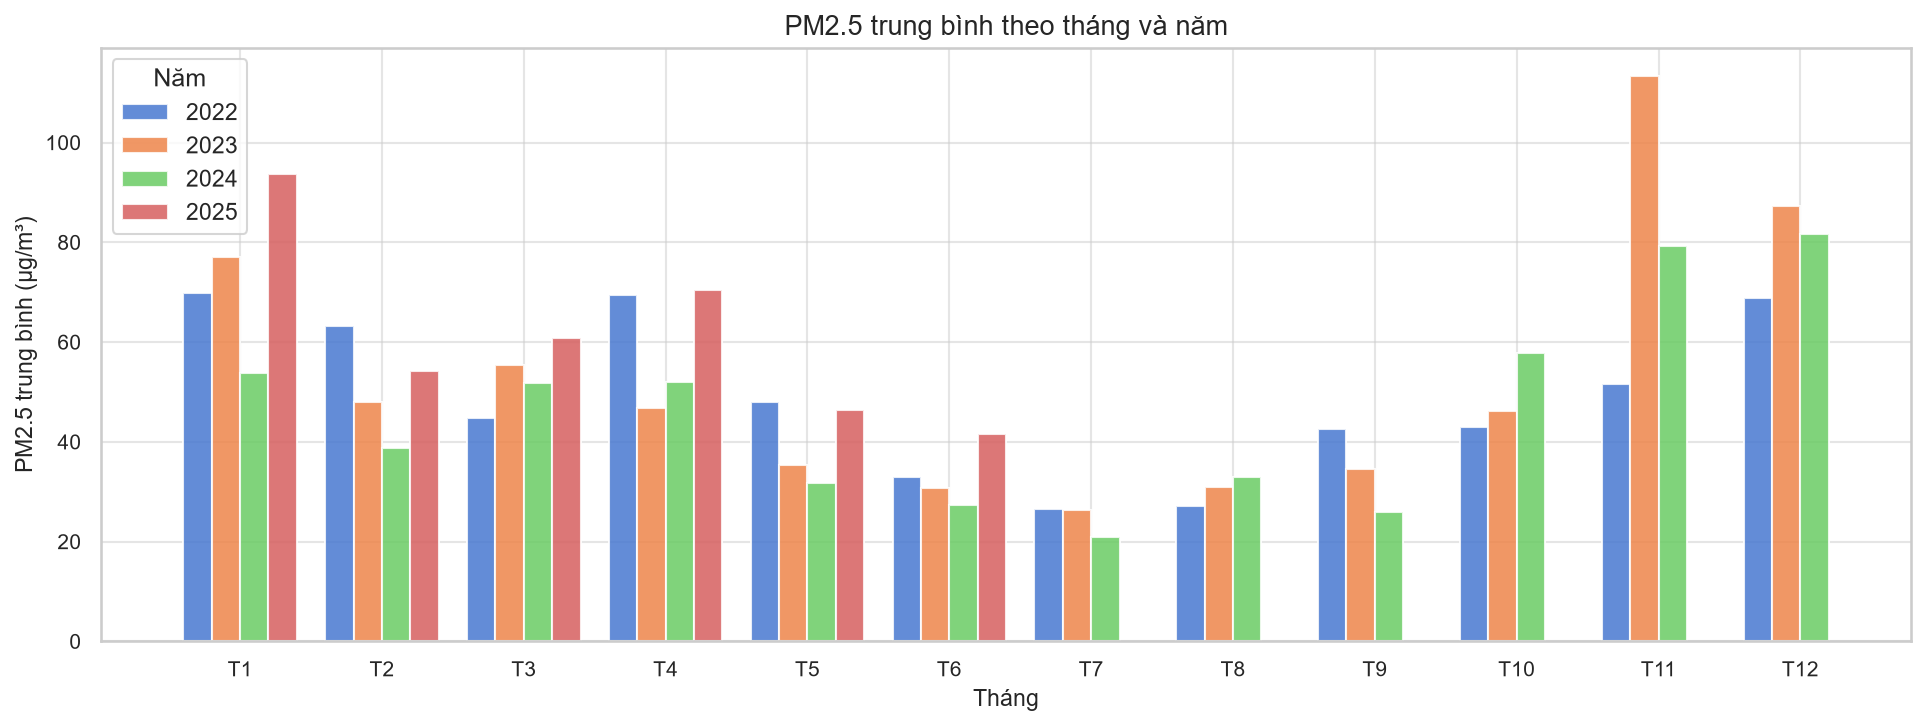

In [6]:
fig = plot_monthly_mean(df)
plt.show()

## 6. Phân tích theo mùa

In [7]:
season_map = {1: 'Xuân (3-5)', 2: 'Hè (6-8)', 3: 'Thu (9-11)', 4: 'Đông (12-2)'}
df_s = df.copy()
month = df_s.index.month
df_s['season'] = pd.cut(month, bins=[0,2,5,8,11,12],
                         labels=[4,1,2,3,4], ordered=False).astype(int)

seasonal = df_s.groupby('season')[TARGET_COL].agg(['mean','median','std']).round(2)
seasonal.index = [season_map[i] for i in seasonal.index]
seasonal.columns = ['Trung bình', 'Trung vị', 'Độ lệch chuẩn']
display(seasonal)

,Trung bình,Trung vị,Độ lệch chuẩn
Xuân (3-5),50.98,44.89,25.53
Hè (6-8),29.71,27.67,12.08
Thu (9-11),54.84,42.21,41.53
Đông (12-2),67.30,61.04,34.20


## 7. ACF và PACF (xác định p, q cho ARIMA)

2026-08-05 20:47:32,681 [INFO] Tập huấn luyện: 1,084 ngày (2022-01-13 → 2024-12-31)
2026-08-05 20:47:32,682 [INFO] Tập kiểm thử:   181 ngày (2025-01-01 → 2025-06-30)
2026-08-05 20:47:32,866 [INFO] Đã lưu biểu đồ: D:\DuAn\QuanLyBuiMinPM25\figures\05_acf_pacf.png


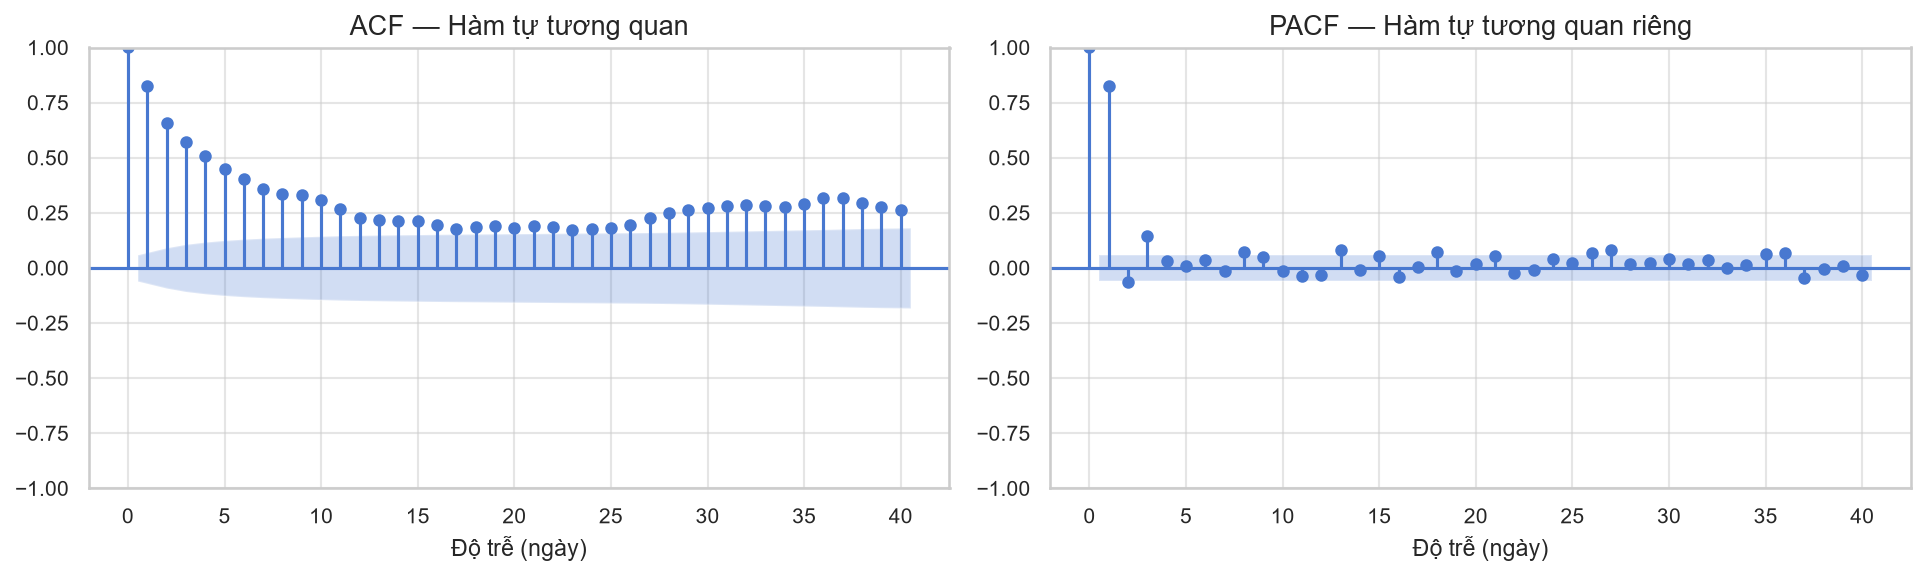


Nhận xét: Xem xét các lag có vạch vượt qua dải tin cậy để chọn p (PACF) và q (ACF).


In [8]:
train, test = split_train_test(df)
fig = plot_acf_pacf(train[TARGET_COL], lags=40)
plt.show()
print('\nNhận xét: Xem xét các lag có vạch vượt qua dải tin cậy để chọn p (PACF) và q (ACF).')

## 8. Các đợt PM2.5 tăng cao (top 10 ngày)

In [9]:
top_days = df[TARGET_COL].nlargest(10).to_frame()
top_days.index = top_days.index.strftime('%Y-%m-%d')
top_days.columns = ['PM2.5 (μg/m³)']
display(top_days.round(2))

,PM2.5 (μg/m³)
date,
2023-11-29,261.01
2023-11-19,253.47
2023-11-21,233.69
2023-11-22,221.82
2023-11-20,212.24
2023-11-23,196.19
2023-11-28,195.79
2023-11-24,195.14
2022-04-08,194.56


---
✅ **Hoàn thành!** Chạy tiếp `03_arima.ipynb`.